## 0. Imports

In [1]:
import math
from IPython.display import display
from qc_circuits import build_circuits
from qc_logs import (
    compute_analysis,
    print_circuits, print_analysis,
    plot_gate_composition, plot_parameter_breakdown,
    plot_execution_counts, plot_fwd_bwd_ratio,
    summary_table,
)

## 1. Configuration

Edit values here to change the experiment — nothing else needs to change.

In [2]:
class CFG:
    # ── quantum architecture ───────────────────────────────
    N_QUBITS          = 3    # qubits per circuit
    N_Q_LAYERS        = 3    # local circuit layers
    N_Q_LAYERS_GLOBAL = 6    # global circuit layers (depth only)
    N_MEASURE_BASES   = 3    # Z, X, Y

    # ── feature map ───────────────────────────────────────
    Q_RES    = 5             # spatial size after interpolation (Q_RES × Q_RES)
    Q_STRIDE = 3             # sliding window stride (local circuit)

    # ── training ──────────────────────────────────────────
    TRAIN_SAMPLES = 1000
    VAL_SAMPLES   = 100
    BATCH_SIZE    = 32
    EPOCHS        = 5

    # ── derived ───────────────────────────────────────────
    @classmethod
    def n_inputs(cls):
        """Total inputs to the global circuit: N_QUBITS × Q_RES²."""
        return cls.N_QUBITS * cls.Q_RES * cls.Q_RES

    @classmethod
    def inputs_per_layer(cls):
        """Inputs distributed evenly across global layers."""
        return math.ceil(cls.n_inputs() / cls.N_Q_LAYERS_GLOBAL)


# ── print summary ─────────────────────────────────────────
print(f"Qubits              : {CFG.N_QUBITS}")
print(f"Local  layers       : {CFG.N_Q_LAYERS}")
print(f"Global layers       : {CFG.N_Q_LAYERS_GLOBAL}")
print(f"Feature map size    : {CFG.Q_RES} × {CFG.Q_RES}")
print(f"Stride              : {CFG.Q_STRIDE}")
print(f"n_inputs            : {CFG.n_inputs()}  ({CFG.N_QUBITS} × {CFG.Q_RES}²)")
print(f"Inputs per gl. layer: {CFG.inputs_per_layer()}")
print(f"Measurement bases   : {CFG.N_MEASURE_BASES}  (Z, X, Y)")
print(f"Train / Val samples : {CFG.TRAIN_SAMPLES}  /  {CFG.VAL_SAMPLES}")
print(f"Batch size / Epochs : {CFG.BATCH_SIZE}  /  {CFG.EPOCHS}")

Qubits              : 3
Local  layers       : 3
Global layers       : 6
Feature map size    : 5 × 5
Stride              : 3
n_inputs            : 75  (3 × 5²)
Inputs per gl. layer: 13
Measurement bases   : 3  (Z, X, Y)
Train / Val samples : 1000  /  100
Batch size / Epochs : 32  /  5


## 2. Build Circuits & Run Full Analysis

Local  — 3 inputs, 9 weights, depth 15
Global — 75 inputs, 18 weights, depth 49

=== LOCAL CIRCUIT ===


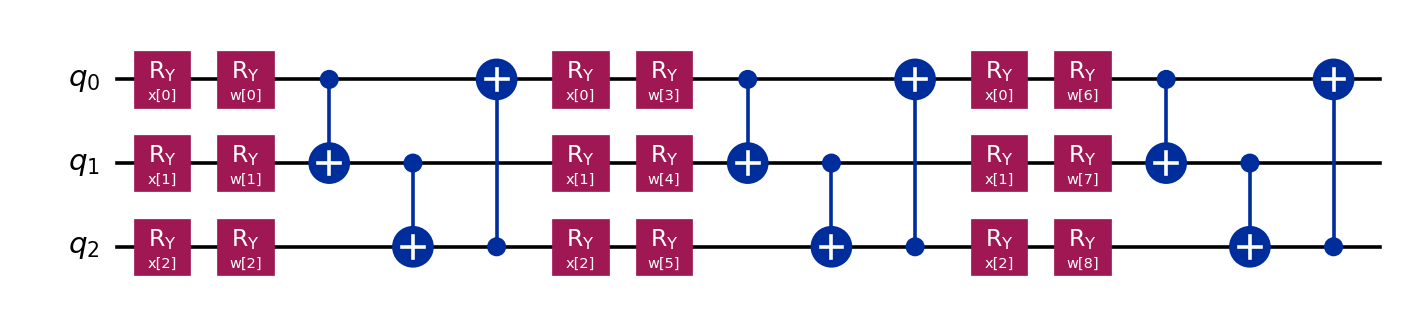


=== GLOBAL CIRCUIT ===


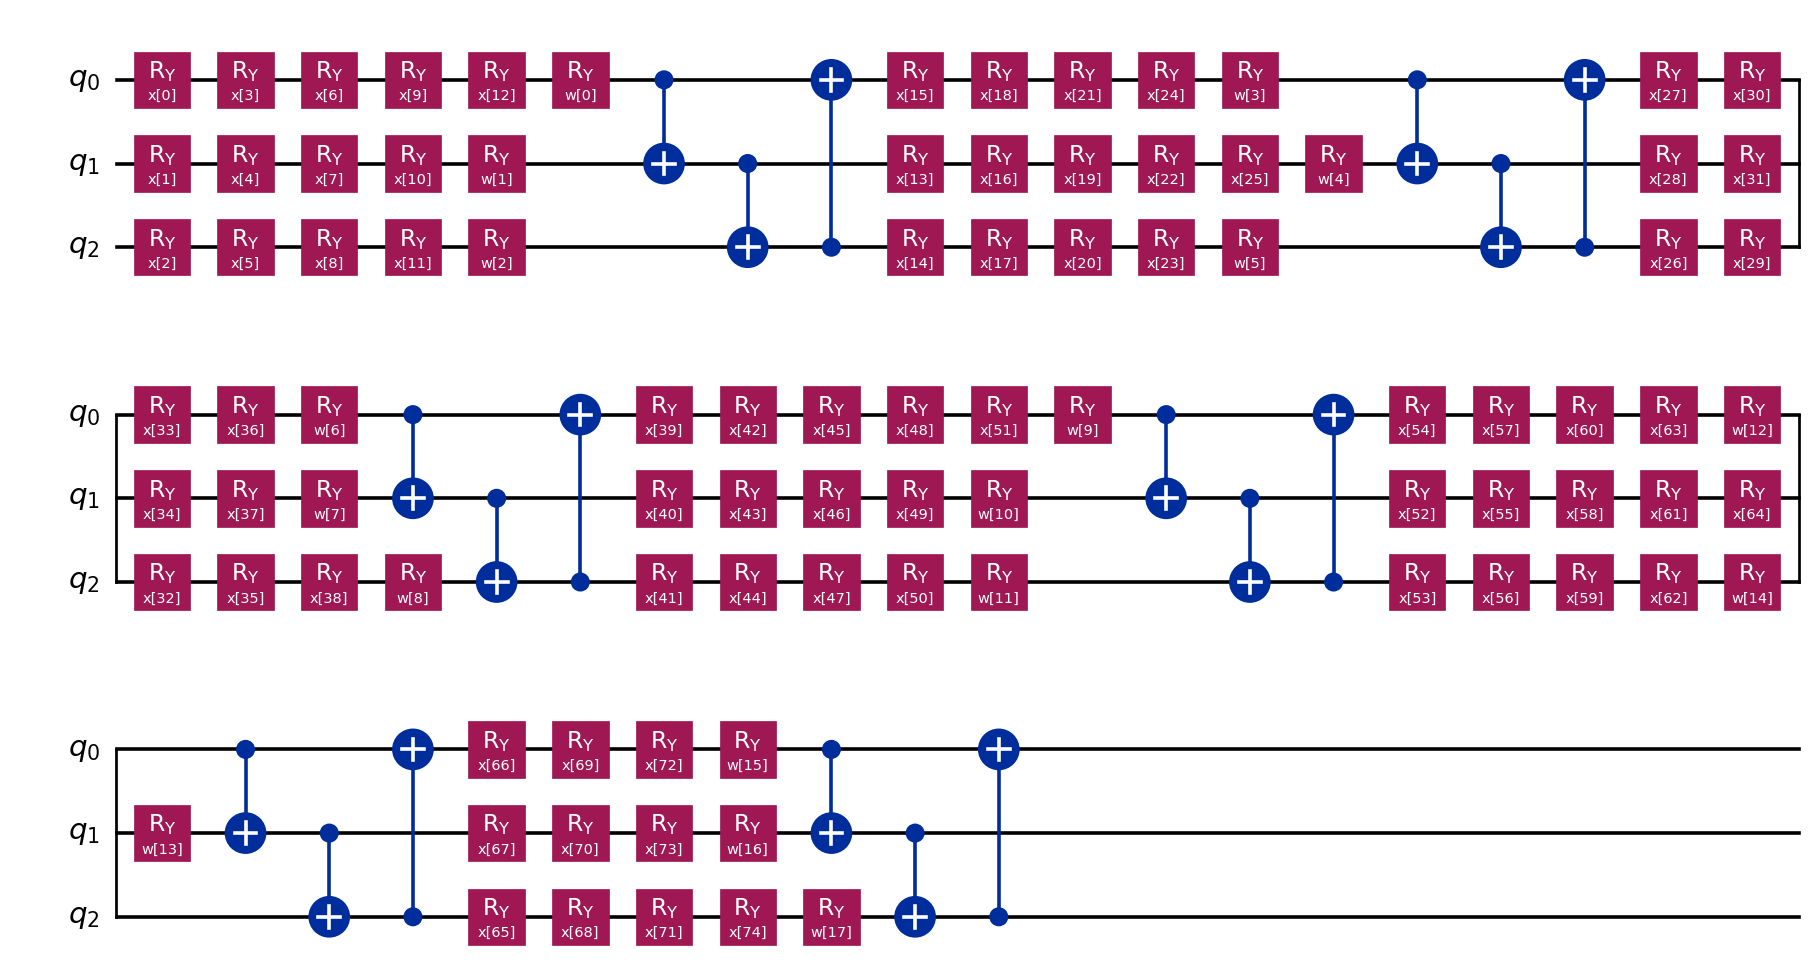

In [3]:
circuits = build_circuits(CFG)
qc_local, qc_global = circuits['qc_local'], circuits['qc_global']

print(f"Local  — {len(circuits['x_local'])} inputs, {len(circuits['w_local'])} weights, depth {qc_local.depth()}")
print(f"Global — {len(circuits['x_global'])} inputs, {len(circuits['w_global'])} weights, depth {qc_global.depth()}")

print("\n=== LOCAL CIRCUIT ===")
display(qc_local.draw(output='mpl', style='iqp', fold=60))

print("\n=== GLOBAL CIRCUIT ===")
display(qc_global.draw(output='mpl', style='iqp', fold=20))

a = compute_analysis(CFG)

## 3. Gate Composition

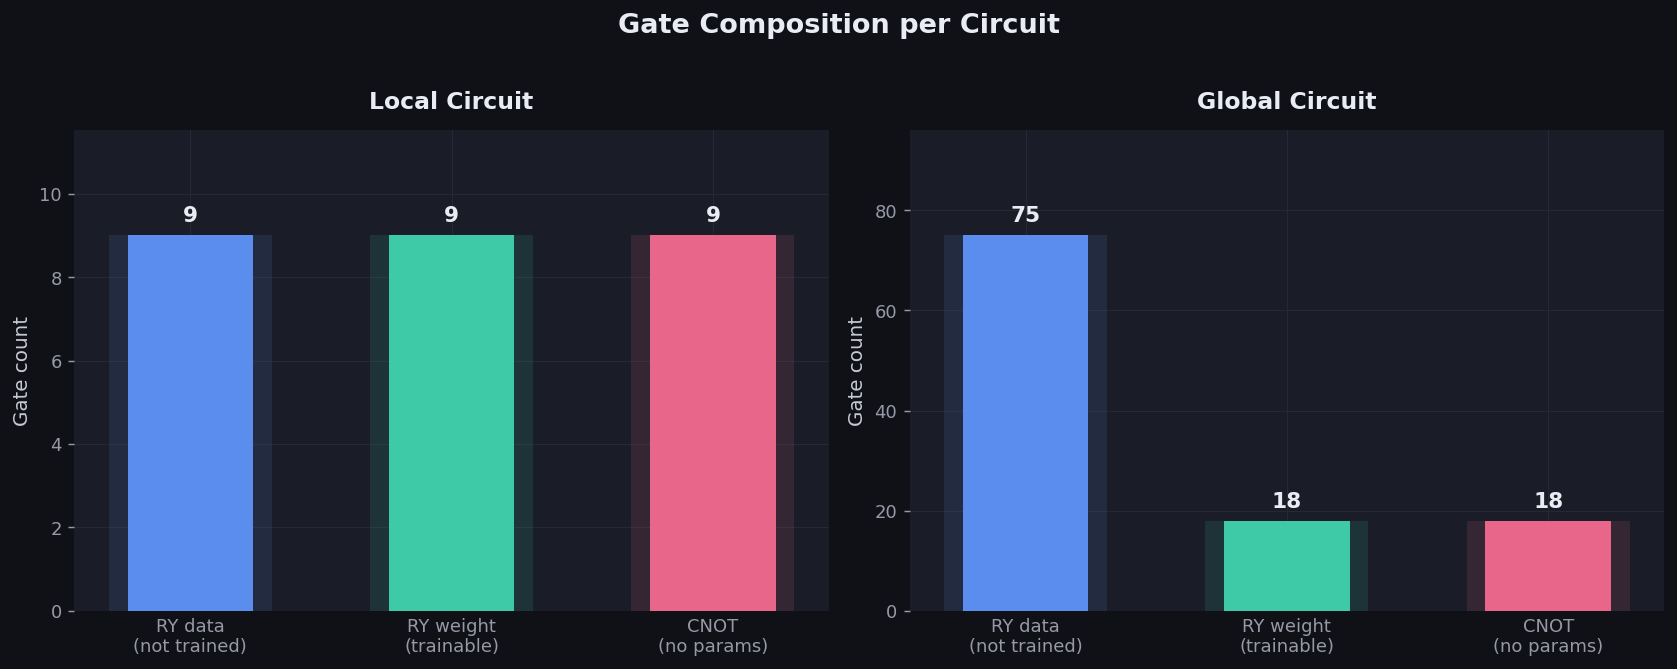

In [4]:
plot_gate_composition(a)

## 4. Parameter Breakdown

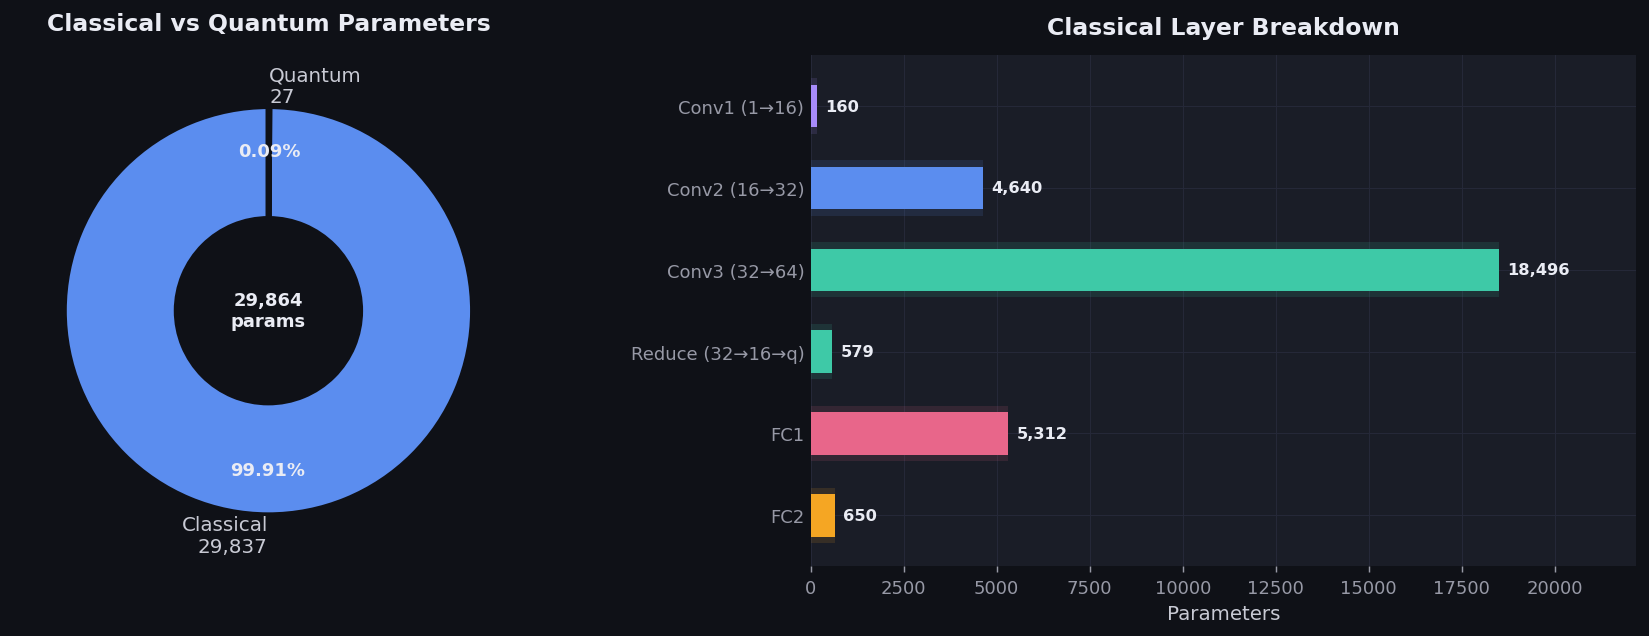

In [5]:
plot_parameter_breakdown(a)

## 5. Circuit Execution Counts

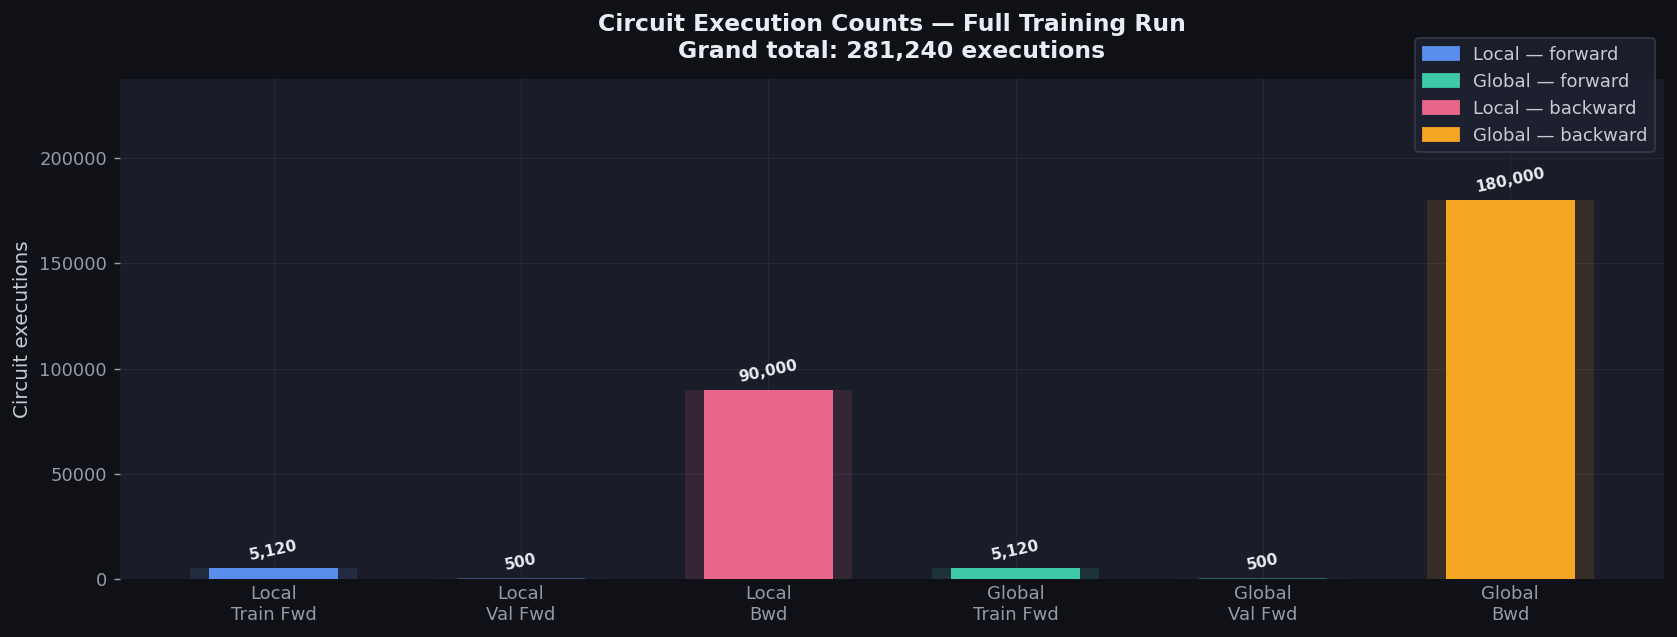

In [6]:
plot_execution_counts(a)

## 6. Forward vs Backward Ratio

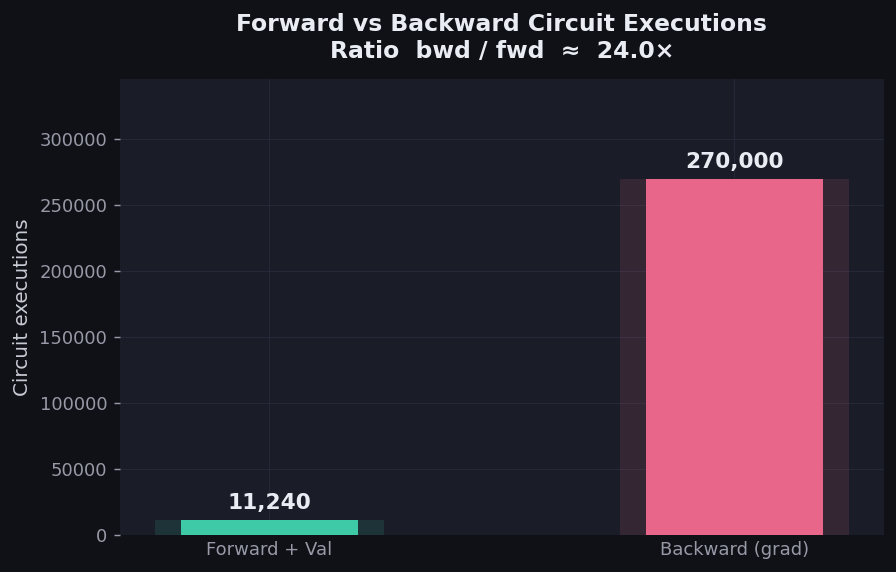

Forward + Val : 11,240
Backward      : 270,000
Ratio bwd/fwd : 24.02×  (parameter-shift dominates)


In [7]:
plot_fwd_bwd_ratio(a)

## 7. Full Text Report

In [8]:
print_circuits(a)
print_analysis(a, CFG)


  LOCAL CIRCUIT  (3 qubits,  3 layers,  3 patch inputs)
     ┌──────────┐┌──────────┐          ┌───┐┌──────────┐┌──────────┐          ┌───┐┌──────────┐»
q_0: ┤ Ry(x[0]) ├┤ Ry(w[0]) ├──■───────┤ X ├┤ Ry(x[0]) ├┤ Ry(w[3]) ├──■───────┤ X ├┤ Ry(x[0]) ├»
     ├──────────┤├──────────┤┌─┴─┐     └─┬─┘├──────────┤├──────────┤┌─┴─┐     └─┬─┘├──────────┤»
q_1: ┤ Ry(x[1]) ├┤ Ry(w[1]) ├┤ X ├──■────┼──┤ Ry(x[1]) ├┤ Ry(w[4]) ├┤ X ├──■────┼──┤ Ry(x[1]) ├»
     ├──────────┤├──────────┤└───┘┌─┴─┐  │  ├──────────┤├──────────┤└───┘┌─┴─┐  │  ├──────────┤»
q_2: ┤ Ry(x[2]) ├┤ Ry(w[2]) ├─────┤ X ├──■──┤ Ry(x[2]) ├┤ Ry(w[5]) ├─────┤ X ├──■──┤ Ry(x[2]) ├»
     └──────────┘└──────────┘     └───┘     └──────────┘└──────────┘     └───┘     └──────────┘»
«     ┌──────────┐          ┌───┐
«q_0: ┤ Ry(w[6]) ├──■───────┤ X ├
«     ├──────────┤┌─┴─┐     └─┬─┘
«q_1: ┤ Ry(w[7]) ├┤ X ├──■────┼──
«     ├──────────┤└───┘┌─┴─┐  │  
«q_2: ┤ Ry(w[8]) ├─────┤ X ├──■──
«     └──────────┘     └───┘     

  GLOBAL CIRCUIT  (3 qubi

## 8. Summary Table

In [9]:
summary_table(a)

Metric,Value
Total model parameters,"29,864"
Classical,"29,837 (99.91%)"
Quantum (local + global),27 (0.09%)
Local circuit — weight params,9
Global circuit — weight params,18
Local circuit — depth,15
Global circuit — depth,49
Patches per sample,1
Grand total circuit executions,"281,240"
of which: backward pass,"270,000 (96.0%)"
